# Pull data

In [253]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

wc_df = pd.read_csv("fifa_wc/results.csv")
print(wc_df.head())

         date home_team away_team  home_score  away_score tournament     city  \
0  1872-11-30  Scotland   England         0.0         0.0   Friendly  Glasgow   
1  1873-03-08   England  Scotland         4.0         2.0   Friendly   London   
2  1874-03-07  Scotland   England         2.0         1.0   Friendly  Glasgow   
3  1875-03-06   England  Scotland         2.0         2.0   Friendly   London   
4  1876-03-04  Scotland   England         3.0         0.0   Friendly  Glasgow   

    country  neutral  
0  Scotland    False  
1   England    False  
2  Scotland    False  
3   England    False  
4  Scotland    False  


In [254]:
elo_wc = pd.read_csv("elo_wc/elo_ratings_wc2026.csv")
print(elo_wc.head())

   year snapshot_date    country  rank country_code  rating  rank_max  \
0  1901    1901-12-31    England     1           EN    2013         1   
1  1901    1901-12-31   Scotland     2           SQ    1973         1   
2  1902    1902-12-31  Argentina     1           AR    2021         1   
3  1902    1902-12-31    England     2           EN    1995         1   
4  1902    1902-12-31   Scotland     3           SQ    1983         1   

   rating_max  rank_avg  rating_avg  ...  matches_home  matches_away  \
0        2079         2        1989  ...            38            35   
1        2104         1        2018  ...            37            37   
2        2021         1        2021  ...             0             1   
3        2079         2        1989  ...            39            38   
4        2104         1        2017  ...            39            40   

   matches_neutral  wins  losses  draws  goals_for  goals_against  \
0                0    46      16     11        262         

# EDA Start

In [255]:

print("Shape:", wc_df.shape)
print("\nColumn types:\n", wc_df.dtypes)
print("\nMissing values per column:")
print(wc_df.isnull().sum())

print("\nMissing % per column:")
print((wc_df.isnull().mean() * 100).round(2))

print("\nNumeric summary:")
print(wc_df.describe())

print("\nCategorical summary:")
print(wc_df.describe(include="object"))


Shape: (49477, 9)

Column types:
 date           object
home_team      object
away_team      object
home_score    float64
away_score    float64
tournament     object
city           object
country        object
neutral          bool
dtype: object

Missing values per column:
date           0
home_team      0
away_team      0
home_score    70
away_score    70
tournament     0
city           0
country        0
neutral        0
dtype: int64

Missing % per column:
date          0.00
home_team     0.00
away_team     0.00
home_score    0.14
away_score    0.14
tournament    0.00
city          0.00
country       0.00
neutral       0.00
dtype: float64

Numeric summary:
         home_score    away_score
count  49407.000000  49407.000000
mean       1.757261      1.181897
std        1.774259      1.402055
min        0.000000      0.000000
25%        1.000000      0.000000
50%        1.000000      1.000000
75%        2.000000      2.000000
max       31.000000     21.000000

Categorical summary:
     

In [256]:

print("Shape:", elo_wc.shape)
print("\nColumn types:\n", elo_wc.dtypes)
print("\nMissing values per column:")
print(elo_wc.isnull().sum())

print("\nMissing % per column:")
print((elo_wc.isnull().mean() * 100).round(2))

print("\nNumeric summary:")
print(elo_wc.describe())

print("\nCategorical summary:")
print(elo_wc.describe(include="object"))


Shape: (4683, 23)

Column types:
 year                int64
snapshot_date      object
country            object
rank                int64
country_code       object
rating              int64
rank_max            int64
rating_max          int64
rank_avg            int64
rating_avg          int64
rank_min            int64
rating_min          int64
matches_total       int64
matches_home        int64
matches_away        int64
matches_neutral     int64
wins                int64
losses              int64
draws               int64
goals_for           int64
goals_against       int64
confederation      object
is_host             int64
dtype: object

Missing values per column:
year               0
snapshot_date      0
country            0
rank               0
country_code       0
rating             0
rank_max           0
rating_max         0
rank_avg           0
rating_avg         0
rank_min           0
rating_min         0
matches_total      0
matches_home       0
matches_away       0
matches_neu

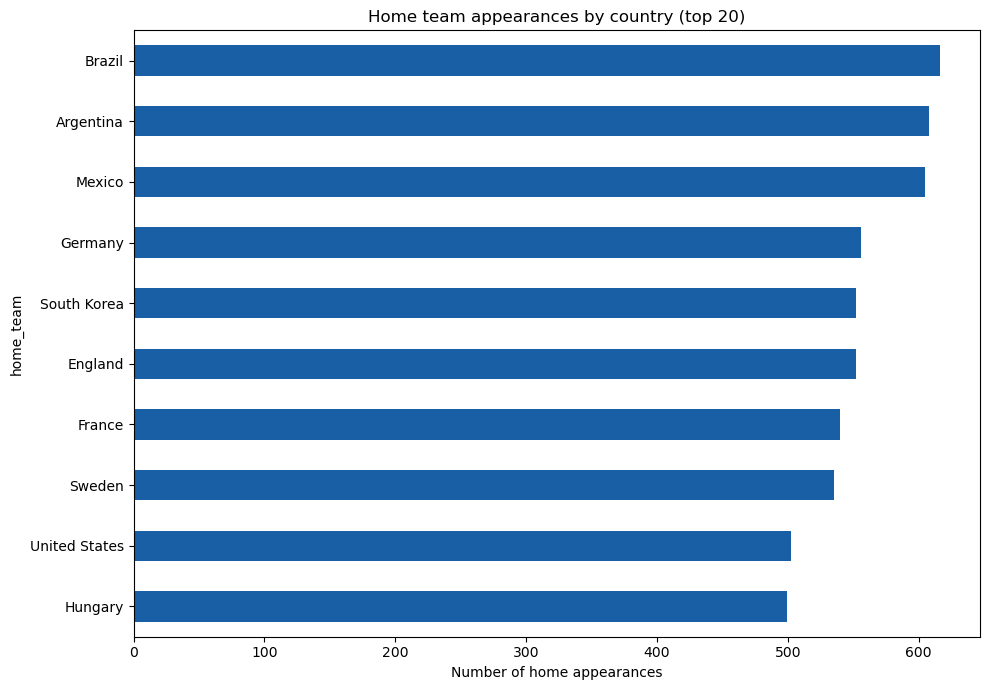

In [257]:
import matplotlib.pyplot as plt

home_counts = wc_df['home_team'].value_counts().head(10)

fig, ax = plt.subplots(figsize=(10, 7))
home_counts.sort_values().plot(kind='barh', ax=ax, color='#185FA5')
ax.set_xlabel('Number of home appearances')
ax.set_title('Home team appearances by country (top 20)')
plt.tight_layout()
plt.show()

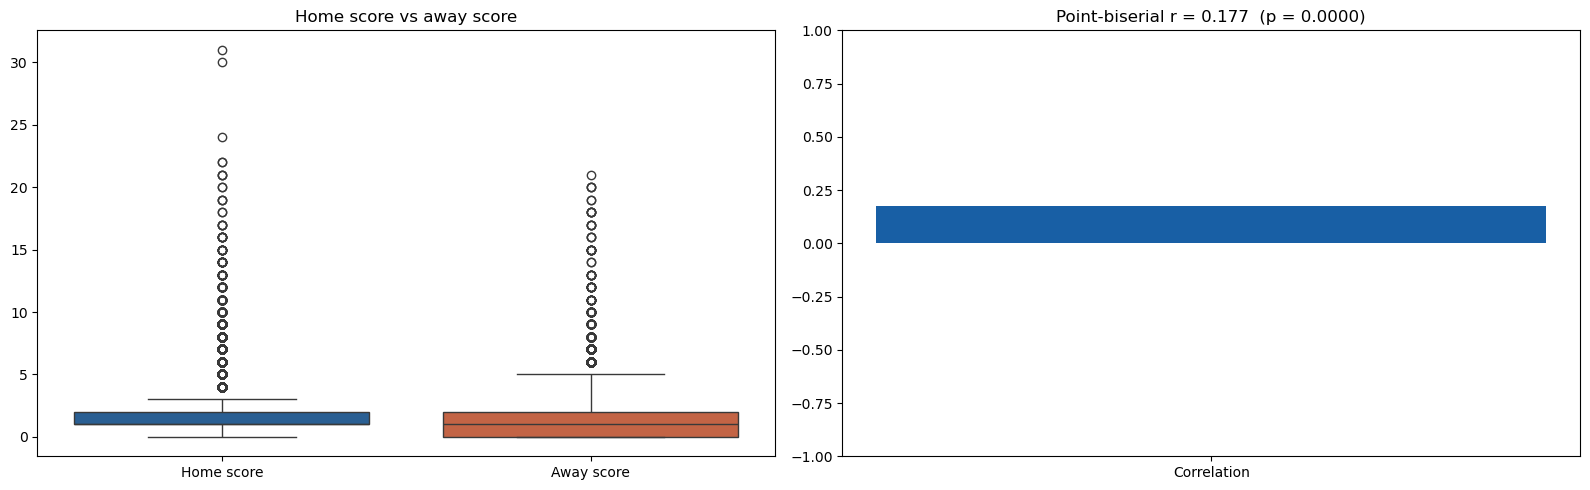

In [258]:
import seaborn as sns
from scipy.stats import pointbiserialr

home = wc_df[['home_score']].copy()
home['type'] = 1

away = wc_df[['away_score']].rename(columns={'away_score': 'home_score'}).copy()
away['type'] = 0

combined = pd.concat([home, away]).reset_index(drop=True)
combined['type'] = combined['type'].astype(str)

clean = combined.dropna(subset=['home_score'])

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
# Boxplot — away score by home/away
away_clean = wc_df[['home_score', 'away_score']].dropna()
sns.boxplot(data=away_clean, ax=axes[0],
            palette={'home_score': '#185FA5', 'away_score': '#D85A30'})
axes[0].set_xticklabels(['Home score', 'Away score'])
axes[0].set_title('Home score vs away score')

# Correlation bar
corr, pval = pointbiserialr(clean['type'].astype(int), clean['home_score'])
axes[1].bar(['Correlation'], [corr], color='#185FA5')
axes[1].set_ylim(-1, 1)
axes[1].set_title(f'Point-biserial r = {corr:.3f}  (p = {pval:.4f})')

plt.tight_layout()
plt.show()

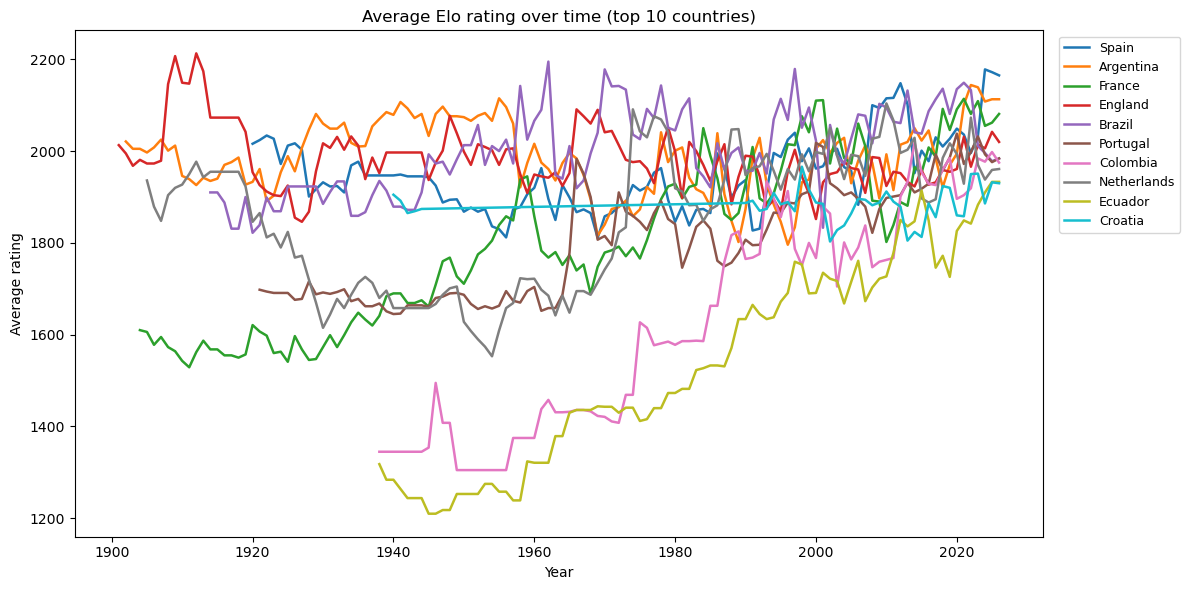

In [259]:
avg_rating = elo_wc.groupby(['country', 'year'])['rating'].mean().reset_index()

# Plot top N countries by latest rating to keep it readable
top_countries = (
    elo_wc.sort_values('year').groupby('country')['rating']
    .last().nlargest(10).index
)

fig, ax = plt.subplots(figsize=(12, 6))
for country in top_countries:
    data = avg_rating[avg_rating['country'] == country]
    ax.plot(data['year'], data['rating'], label=country, linewidth=1.8)

ax.set_title('Average Elo rating over time (top 10 countries)')
ax.set_xlabel('Year')
ax.set_ylabel('Average rating')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

# Take only data from 2000 - data cleaning

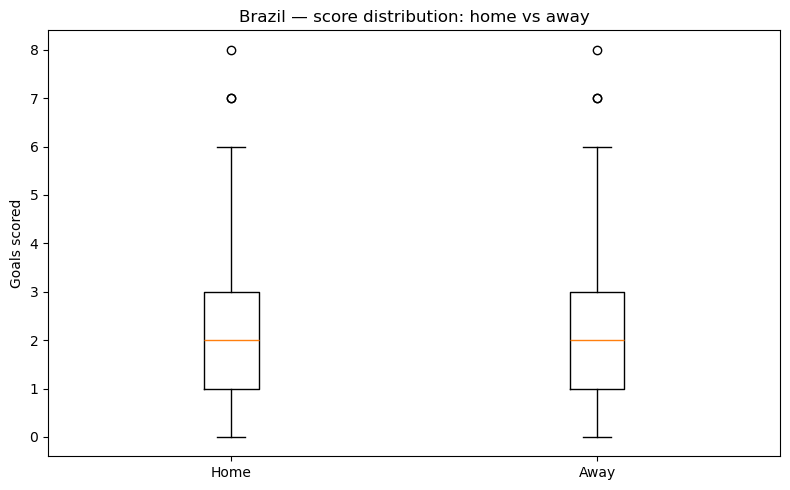

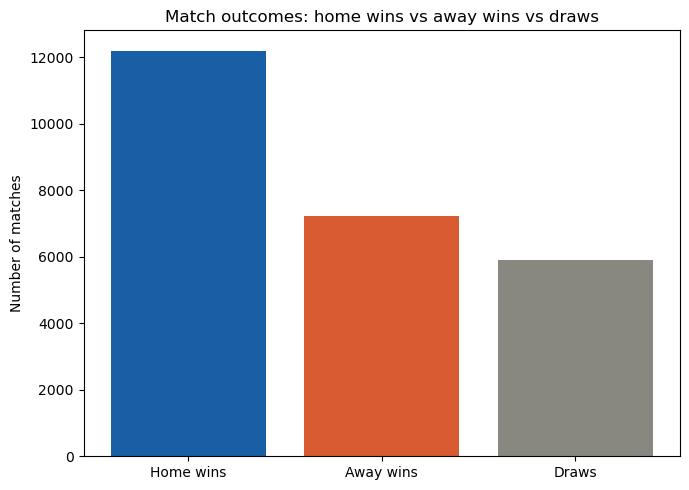

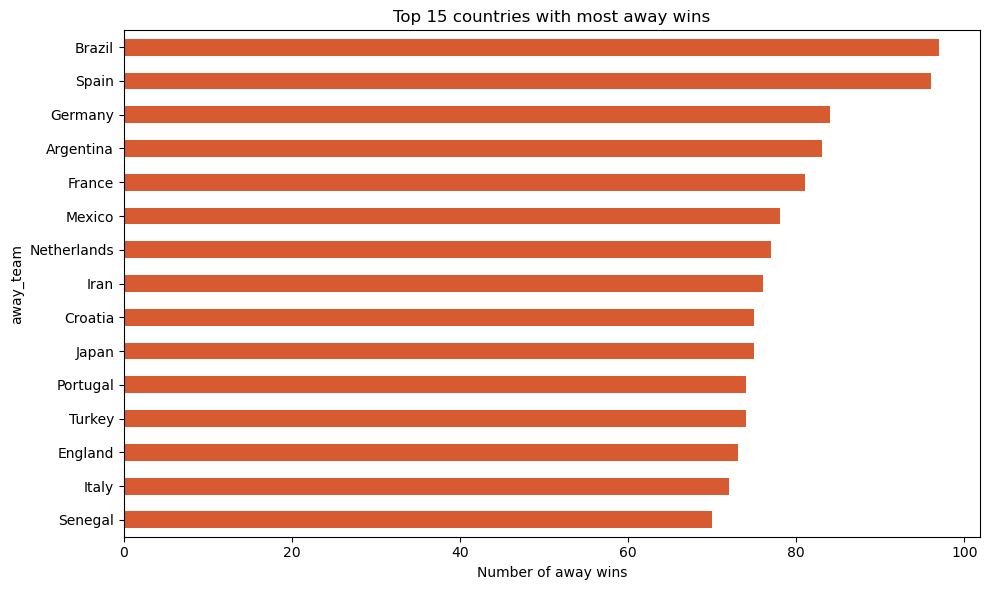

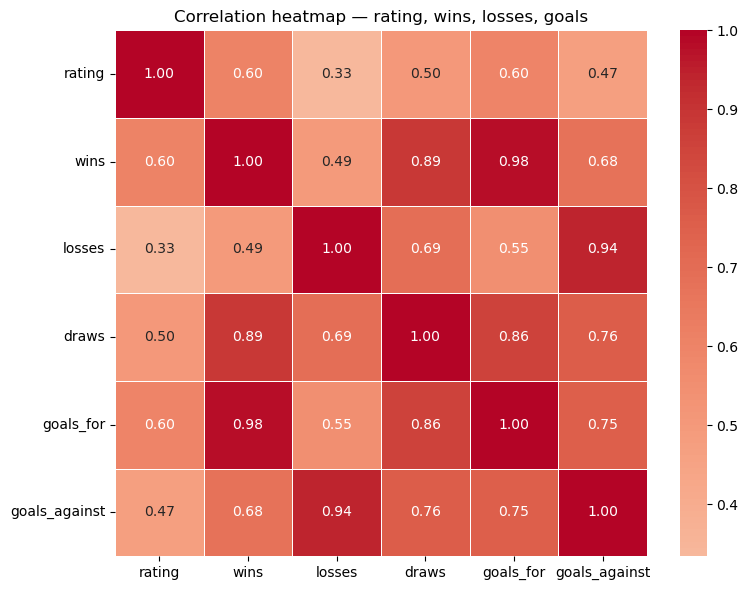

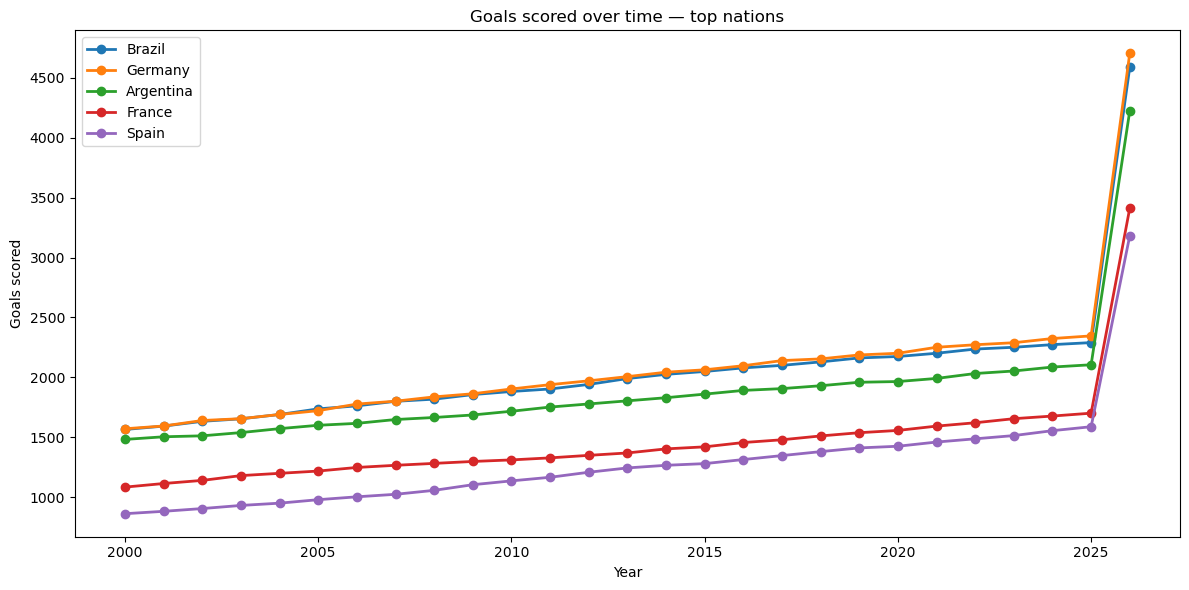

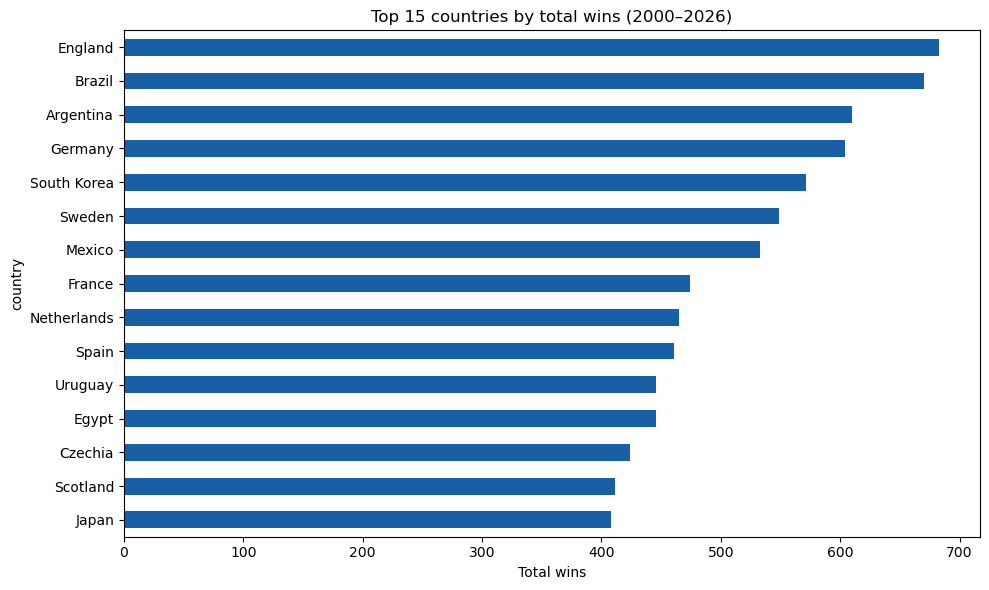

In [260]:
# Filter both datasets from year 2000
wc_df['year'] = wc_df['date'].astype(str).str[:4].astype(int)  # already snapshotcted as year
wc_filtered = wc_df[wc_df['year'] >= 2000]
elo_filtered = elo_wc[elo_wc['year'] >= 2000]

# ── 1. Home advantage for Brazil ──────────────────────────────────────────────
brazil_home = wc_filtered[wc_filtered['home_team'] == 'Brazil']['home_score'].dropna()
brazil_away = wc_filtered[wc_filtered['away_team'] == 'Brazil']['away_score'].dropna()

fig, ax = plt.subplots(figsize=(8, 5))
ax.boxplot([brazil_home, brazil_away], labels=['Home', 'Away'])
ax.set_title('Brazil — score distribution: home vs away')
ax.set_ylabel('Goals scored')
plt.tight_layout()
plt.show()

# ── 2. Wins at home vs not at home (overall) ──────────────────────────────────
home_wins = (wc_filtered['home_score'] > wc_filtered['away_score']).sum()
away_wins = (wc_filtered['away_score'] > wc_filtered['home_score']).sum()
draws     = (wc_filtered['home_score'] == wc_filtered['away_score']).sum()

fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(['Home wins', 'Away wins', 'Draws'], [home_wins, away_wins, draws],
       color=['#185FA5', '#D85A30', '#888780'])
ax.set_title('Match outcomes: home wins vs away wins vs draws')
ax.set_ylabel('Number of matches')
plt.tight_layout()
plt.show()

# ── 3. Countries with most away wins ──────────────────────────────────────────
away_win_matches = wc_filtered[wc_filtered['away_score'] > wc_filtered['home_score']]
top_away_wins = away_win_matches['away_team'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(10, 6))
top_away_wins.sort_values().plot(kind='barh', ax=ax, color='#D85A30')
ax.set_title('Top 15 countries with most away wins')
ax.set_xlabel('Number of away wins')
plt.tight_layout()
plt.show()

# ── 4. Correlation: rating vs wins & losses ───────────────────────────────────
corr_cols = elo_filtered[['rating', 'wins', 'losses', 'draws', 'goals_for', 'goals_against']].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_cols, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=ax, linewidths=0.5)
ax.set_title('Correlation heatmap — rating, wins, losses, goals')
plt.tight_layout()
plt.show()

top_countries = ['Brazil', 'Germany', 'Argentina', 'France', 'Spain']
goals_over_time = (
    elo_filtered[elo_filtered['country'].isin(top_countries)]
    .groupby(['year', 'country'])['goals_for']
    .sum()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(12, 6))
for country in top_countries:
    data = goals_over_time[goals_over_time['country'] == country]
    ax.plot(data['year'], data['goals_for'], marker='o', linewidth=2, label=country)
ax.set_title('Goals scored over time — top nations')
ax.set_xlabel('Year')
ax.set_ylabel('Goals scored')
ax.legend()
plt.tight_layout()
plt.show()

# ── 6. Country with most total wins ───────────────────────────────────────────
top_wins = elo_filtered.groupby('country')['wins'].max().nlargest(15).sort_values()

fig, ax = plt.subplots(figsize=(10, 6))
top_wins.plot(kind='barh', ax=ax, color='#185FA5')
ax.set_title('Top 15 countries by total wins (2000–2026)')
ax.set_xlabel('Total wins')
plt.tight_layout()
plt.show()

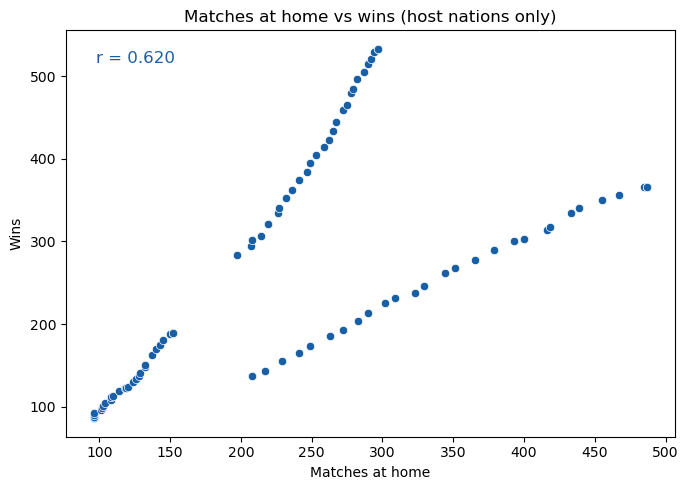

In [261]:
# ── 1. Correlation: matches_home vs wins when is_host = 1 ────────────────────
host_df = elo_filtered[elo_filtered['is_host'] == 1][['matches_home', 'wins']].dropna()

fig, ax = plt.subplots(figsize=(7, 5))
sns.scatterplot(data=host_df, x='matches_home', y='wins', ax=ax, color='#185FA5')
ax.set_title('Matches at home vs wins (host nations only)')
ax.set_xlabel('Matches at home')
ax.set_ylabel('Wins')

corr = host_df['matches_home'].corr(host_df['wins'])
ax.annotate(f'r = {corr:.3f}', xy=(0.05, 0.92), xycoords='axes fraction',
            fontsize=12, color='#185FA5')
plt.tight_layout()
plt.show()

In [262]:
home_higher = (wc_filtered['home_score'] > wc_filtered['away_score']).sum()
away_higher = (wc_filtered['away_score'] > wc_filtered['home_score']).sum()
draws       = (wc_filtered['home_score'] == wc_filtered['away_score']).sum()
total       = wc_filtered[['home_score', 'away_score']].dropna().shape[0]

print(f"Home score higher : {home_higher} ({home_higher/total:.1%})")
print(f"Away score higher : {away_higher} ({away_higher/total:.1%})")
print(f"Draws             : {draws} ({draws/total:.1%})")
print(f"Total matches     : {total}")

Home score higher : 12204 (48.2%)
Away score higher : 7238 (28.6%)
Draws             : 5903 (23.3%)
Total matches     : 25345


In [263]:
wc_filtered["neutral"].value_counts()

neutral
False    18121
True      7294
Name: count, dtype: int64

In [264]:
elo_filtered["matches_neutral"].value_counts()

matches_neutral
51     20
48     16
40     15
56     15
66     14
       ..
339     1
300     1
303     1
324     1
252     1
Name: count, Length: 323, dtype: int64

# Feature Engineering

## Calculate score from win, loss, and draw count

In [265]:
elo_filtered['form_score'] = (
    (elo_filtered['wins'] * 3 + elo_filtered['draws'] * 1) / # losses are multiplied with zero
    (elo_filtered['matches_total'] * 3)  
)

elo_filtered.drop(columns=["wins", "draws", "losses"])

,year,snapshot_date,country,rank,country_code,rating,rank_max,rating_max,rank_avg,rating_avg,...,rating_min,matches_total,matches_home,matches_away,matches_neutral,goals_for,goals_against,confederation,is_host,form_score
3339,2000,2000-12-31,France,1,FR,2110,1,2131,19,1743,...,1514,606,305,240,61,1084,1021,UEFA,0,0.511001
3340,2000,2000-12-31,Brazil,2,BR,2023,1,2195,5,1981,...,1805,709,275,228,206,1565,703,CONMEBOL,0,0.693935
3341,2000,2000-12-31,Portugal,3,PT,2018,3,2018,22,1751,...,1624,377,177,159,41,559,514,UEFA,0,0.496021
3342,2000,2000-12-31,Argentina,5,AR,2005,1,2159,5,1979,...,1751,782,293,303,186,1482,865,CONMEBOL,0,0.603581
3343,2000,2000-12-31,Netherlands,6,NL,1998,1,2109,17,1810,...,1553,597,289,242,66,1253,882,UEFA,0,0.544389
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4678,2026,2026-05-27,Haiti,77,HT,1532,37,1673,81,1417,...,1265,561,181,196,184,957,759,CONCACAF,0,0.508616
4679,2026,2026-05-27,South Africa,79,ZA,1524,7,1847,32,1707,...,1448,524,275,161,88,719,542,CAF,0,0.537532
4680,2026,2026-05-27,Ghana,82,GH,1503,10,1877,42,1651,...,1424,778,247,297,234,1247,822,CAF,0,0.559126
4681,2026,2026-05-27,Curaçao,90,CW,1436,26,1618,97,1381,...,1011,498,173,176,149,879,767,CONCACAF,0,0.486613


In [266]:
elo_snapshot = (
    elo_filtered.sort_values('year')
    .groupby(['country', 'year'])
    .last()
    .reset_index()
)[['country', 'year', 'rating', 'form_score', 'wins', 'matches_home', 'matches_away', 'matches_total']]


In [267]:
elo_snapshot['home_win_rate'] = elo_snapshot['wins'] / elo_snapshot['matches_home'].replace(0, np.nan)
elo_snapshot['away_win_rate'] = elo_snapshot['wins'] / elo_snapshot['matches_away'].replace(0, np.nan)
elo_snapshot = elo_snapshot.fillna(0).drop(columns=["wins", "matches_home", "matches_away", "matches_total"])


In [268]:
print(wc_filtered.head(5))
print(elo_snapshot.head())

             date            home_team away_team  home_score  away_score  \
24062  2000-01-04                Egypt      Togo         2.0         1.0   
24063  2000-01-07              Tunisia      Togo         7.0         0.0   
24064  2000-01-08  Trinidad and Tobago    Canada         0.0         0.0   
24065  2000-01-09         Burkina Faso     Gabon         1.0         1.0   
24066  2000-01-09            Guatemala   Armenia         1.0         1.0   

      tournament           city              country  neutral  year  
24062   Friendly          Aswan                Egypt    False  2000  
24063   Friendly          Tunis              Tunisia    False  2000  
24064   Friendly  Port of Spain  Trinidad and Tobago    False  2000  
24065   Friendly    Ouagadougou         Burkina Faso    False  2000  
24066   Friendly    Los Angeles        United States     True  2000  
   country  year  rating  form_score  home_win_rate  away_win_rate
0  Algeria  2000    1507    0.492969       1.073826     

In [269]:
# ── start fresh from wc_filtered without elo columns ─────────────────────────
cols_to_drop = [c for c in wc_filtered.columns if any(x in c for x in ['elo', 'form_score'])]
wc_filtered  = wc_filtered.drop(columns=cols_to_drop)

elo_snapshot = elo_snapshot.sort_values('year')  # sort right key first

wc_filtered = pd.merge_asof(
    wc_filtered.sort_values('year'),
    elo_snapshot.rename(columns={'country': 'home_team', 
                            'rating': 'home_elo', 
                            'form_score': 'home_form_score',
                            'home_win_rate': 'home_team_home_winrate',
                            'away_win_rate': 'home_team_away_winrate'}),
    on='year', by='home_team', direction='backward'
)

wc_filtered = pd.merge_asof(
    wc_filtered.sort_values('year'),
    elo_snapshot.rename(columns={'country': 'away_team', 
                                'rating': 'away_elo', 
                                'form_score': 'away_form_score',
                                'home_win_rate': 'away_team_home_winrate',
                                'away_win_rate': 'away_team_away_winrate',}),
    on='year', by='away_team', direction='backward'
)

wc_filtered['elo_diff'] = wc_filtered['home_elo'] - wc_filtered['away_elo']
wc_filtered['form_score_diff'] = wc_filtered['home_form_score'] - wc_filtered['away_form_score']

print(wc_filtered[['home_team', 'away_team', 'year', 'home_elo', 'away_elo', 'form_score_diff', 'elo_diff', 'home_team_home_winrate', 'home_team_away_winrate',
                    'away_team_home_winrate', 'away_team_away_winrate']].head(10))
print(f"\nNaNs: home_elo={wc_filtered['home_elo'].isna().sum()}, away_elo={wc_filtered['away_elo'].isna().sum()}")

             home_team            away_team  year  home_elo  away_elo  \
0                Egypt                 Togo  2000    1682.0       NaN   
1  Trinidad and Tobago               Canada  2000       NaN    1632.0   
2               Mexico  Republic of Ireland  2000    1824.0       NaN   
3            Guatemala              Armenia  2000       NaN       NaN   
4          Ivory Coast                Egypt  2000    1572.0    1682.0   
5               Mexico                 Iran  2000    1824.0    1743.0   
6              Bermuda               Canada  2000       NaN    1632.0   
7         Burkina Faso             Cameroon  2000       NaN       NaN   
8              Senegal             Cameroon  2000    1454.0       NaN   
9                China          New Zealand  2000       NaN    1540.0   

   form_score_diff  elo_diff  home_team_home_winrate  home_team_away_winrate  \
0              NaN       NaN                1.256281                1.308901   
1              NaN       NaN        

In [270]:
# ── check name mismatches ─────────────────────────────────────────────────────
wc_teams   = set(wc_filtered['home_team'].unique()) | set(wc_filtered['away_team'].unique())
elo_teams  = set(elo_snapshot['country'].unique())

in_wc_not_elo = wc_teams - elo_teams
in_elo_not_wc = elo_teams - wc_teams

print(f"Teams in wc_filtered but NOT in elo_snapshot ({len(in_wc_not_elo)}):")
print(sorted(in_wc_not_elo))

print(f"\nTeams in elo_snapshot but NOT in wc_filtered ({len(in_elo_not_wc)}):")
print(sorted(in_elo_not_wc))

Teams in wc_filtered but NOT in elo_snapshot (274):
['Abkhazia', 'Afghanistan', 'Albania', 'Alderney', 'Ambazonia', 'American Samoa', 'Andalusia', 'Andorra', 'Angola', 'Anguilla', 'Antigua and Barbuda', 'Arameans Suryoye', 'Armenia', 'Artsakh', 'Aruba', 'Aymara', 'Azerbaijan', 'Bahamas', 'Bahrain', 'Bangladesh', 'Barawa', 'Barbados', 'Basque Country', 'Belarus', 'Belize', 'Benin', 'Bermuda', 'Bhutan', 'Biafra', 'Bolivia', 'Bonaire', 'Botswana', 'British Virgin Islands', 'Brittany', 'Brunei', 'Bulgaria', 'Burkina Faso', 'Burundi', 'Cambodia', 'Cameroon', 'Canary Islands', 'Cascadia', 'Catalonia', 'Cayman Islands', 'Central African Republic', 'Chad', 'Chagos Islands', 'Chameria', 'Chechnya', 'Chile', 'China', 'Cilento', 'Comoros', 'Congo', 'Cook Islands', 'Corsica', 'Costa Rica', 'County of Nice', 'Crimea', 'Cuba', 'Cyprus', 'Czech Republic', 'Darfur', 'Denmark', 'Djibouti', 'Dominica', 'Dominican Republic', 'Donetsk PR', 'Délvidék', 'East Turkestan', 'El Salvador', 'Elba Island', 'Ellan

#### Most of these teams are non FIFA, so we remove them 

#### Note we removed Italy which has a lot of data so we can see how this model performs, I mean Italy didn't qualify so whatever


In [271]:
wc_filtered['home_team'] = wc_filtered['home_team'].replace({'Czech Republic': 'Czechia'})
wc_filtered['away_team'] = wc_filtered['away_team'].replace({'Czech Republic': 'Czechia'})

# ── 2. after merging elo, drop rows where elo is missing (non-FIFA teams) ─────
wc_filtered = wc_filtered.dropna(subset=['home_elo', 'away_elo'])

print(f"Shape after dropping non-FIFA matches: {wc_filtered.shape}")
print(f"Remaining NaNs: home_elo={wc_filtered['home_elo'].isna().sum()}, away_elo={wc_filtered['away_elo'].isna().sum()}")

Shape after dropping non-FIFA matches: (3202, 20)
Remaining NaNs: home_elo=0, away_elo=0


In [272]:
wc_filtered.head()

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,year,home_elo,home_form_score,home_team_home_winrate,home_team_away_winrate,away_elo,away_form_score,away_team_home_winrate,away_team_away_winrate,elo_diff,form_score_diff
4,2000-01-09,Ivory Coast,Egypt,2.0,0.0,Friendly,Abidjan,Ivory Coast,False,2000,1572.0,0.553872,1.128049,1.275862,1682.0,0.552876,1.256281,1.308901,-110.0,0.000996
5,2000-01-09,Mexico,Iran,2.0,1.0,Friendly,Oakland,United States,True,2000,1824.0,0.580399,1.436548,1.607955,1743.0,0.612805,1.692308,2.172840,81.0,-0.032406
11,2000-01-16,United States,Iran,1.0,1.0,Friendly,Pasadena,United States,False,2000,1808.0,0.415435,0.658654,0.889610,1743.0,0.612805,1.692308,2.172840,65.0,-0.197370
12,2000-01-18,Ghana,Tunisia,2.0,0.0,Friendly,Accra,Ghana,False,2000,1509.0,0.584551,1.460606,1.229592,1637.0,0.483988,0.882353,1.090909,-128.0,0.100563
18,2000-01-21,New Zealand,South Korea,0.0,1.0,Friendly,Auckland,New Zealand,False,2000,1540.0,0.480247,1.200000,0.966102,1764.0,0.649202,2.128492,2.177143,-224.0,-0.168955


## Make result column

In [273]:
wc_filtered['result'] = wc_filtered.apply(
    lambda r: 1 if r['home_score'] > r['away_score'] else (-1 if r['home_score'] < r['away_score'] else 0), axis=1
)

print(wc_filtered['result'].value_counts())
print(f"\nHome win rate : {(wc_filtered['result'] == 1).mean():.2%}")
print(f"Away win rate : {(wc_filtered['result'] == -1).mean():.2%}")
print(f"Draw rate     : {(wc_filtered['result'] == 0).mean():.2%}")

result
 1    1410
 0     899
-1     893
Name: count, dtype: int64

Home win rate : 44.03%
Away win rate : 27.89%
Draw rate     : 28.08%


In [274]:
def map_tournament_weight(tournament):
    t = str(tournament).lower()
    if 'world cup' in t and 'qualification' not in t:
        return 5
    elif any(x in t for x in ['euro', 'copa américa', 'asian cup', 'african cup', 'gold cup', 'confederations']):
        return 4
    elif 'qualification' in t or 'nations league' in t:
        return 3
    elif any(x in t for x in ['championship', 'arab cup', 'gulf cup', 'cosafa', 'waff', 'eaff', 'cafa']):
        return 2
    else:
        return 1  # friendlies and invitationals

In [275]:
wc_filtered['tournament_weight'] = wc_filtered['tournament'].apply(map_tournament_weight)

In [276]:
wc_filtered["goal_diff"] = wc_filtered["home_score"] - wc_filtered["away_score"]
wc_filtered['goal_diff'] = wc_filtered['goal_diff'].fillna(0)

In [277]:
wc_filtered['is_home'] = (
    (wc_filtered['home_team'] == wc_filtered['country']) & 
    (wc_filtered['neutral'] == False)
).astype(int)

In [278]:
match_filtered = wc_filtered.copy() # We still need the home and away score for poisson distribution
match_filtered = match_filtered.drop(columns=["home_score", "away_score"])

## Poisson distribution to calculate goal

In [279]:
from scipy.stats import poisson

# ── 1. League averages (from wc_filtered) ────────────────────────────────────
total_matches = wc_filtered[['home_score', 'away_score']].dropna().shape[0]

avg_home_scored   = wc_filtered['home_score'].sum() / total_matches  # attack baseline at home
avg_away_scored   = wc_filtered['away_score'].sum() / total_matches  # attack baseline away
avg_home_conceded = avg_away_scored  # home team concedes what away team scores
avg_away_conceded = avg_home_scored  # away team concedes what home team scores

print(f"Avg goals scored  at home : {avg_home_scored:.3f}")
print(f"Avg goals scored  away    : {avg_away_scored:.3f}")
print(f"Avg goals conceded at home: {avg_home_conceded:.3f}")
print(f"Avg goals conceded away   : {avg_away_conceded:.3f}")

Avg goals scored  at home : 1.466
Avg goals scored  away    : 1.080
Avg goals conceded at home: 1.080
Avg goals conceded away   : 1.466


# Final data cleaning

In [280]:
match_filtered.head()

,date,home_team,away_team,tournament,city,country,neutral,year,home_elo,home_form_score,...,away_elo,away_form_score,away_team_home_winrate,away_team_away_winrate,elo_diff,form_score_diff,result,tournament_weight,goal_diff,is_home
4,2000-01-09,Ivory Coast,Egypt,Friendly,Abidjan,Ivory Coast,False,2000,1572.0,0.553872,...,1682.0,0.552876,1.256281,1.308901,-110.0,0.000996,1,1,2.0,1
5,2000-01-09,Mexico,Iran,Friendly,Oakland,United States,True,2000,1824.0,0.580399,...,1743.0,0.612805,1.692308,2.172840,81.0,-0.032406,1,1,1.0,0
11,2000-01-16,United States,Iran,Friendly,Pasadena,United States,False,2000,1808.0,0.415435,...,1743.0,0.612805,1.692308,2.172840,65.0,-0.197370,0,1,0.0,1
12,2000-01-18,Ghana,Tunisia,Friendly,Accra,Ghana,False,2000,1509.0,0.584551,...,1637.0,0.483988,0.882353,1.090909,-128.0,0.100563,1,1,2.0,1
18,2000-01-21,New Zealand,South Korea,Friendly,Auckland,New Zealand,False,2000,1540.0,0.480247,...,1764.0,0.649202,2.128492,2.177143,-224.0,-0.168955,-1,1,-1.0,1


In [281]:
match_filtered = match_filtered.drop(columns=["date","city","country"])

In [282]:
match_filtered.columns

Index(['home_team', 'away_team', 'tournament', 'neutral', 'year', 'home_elo',
       'home_form_score', 'home_team_home_winrate', 'home_team_away_winrate',
       'away_elo', 'away_form_score', 'away_team_home_winrate',
       'away_team_away_winrate', 'elo_diff', 'form_score_diff', 'result',
       'tournament_weight', 'goal_diff', 'is_home'],
      dtype='object')

In [283]:
match_filtered = match_filtered.drop(columns=["home_elo", "away_elo", "home_form_score", "away_form_score", "tournament","home_team", "away_team"])

In [293]:
match_filtered = match_filtered.sort_values('year').reset_index(drop=True)

In [294]:
match_filtered = match_filtered.drop(columns=["year"])

# Predict Winning Or Losing with ML Algorithm

In [284]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

In [295]:
X = match_filtered.drop(columns=["result"])
y = match_filtered["result"]


In [297]:
X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.2, random_state=42, stratify=y
        )

In [298]:
X_train.isna().sum()

neutral                   0
home_team_home_winrate    0
home_team_away_winrate    0
away_team_home_winrate    0
away_team_away_winrate    0
elo_diff                  0
form_score_diff           0
tournament_weight         0
goal_diff                 0
is_home                   0
dtype: int64

In [299]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train[["form_score_diff", "elo_diff"]])
X_test_scaled = scaler.transform(X_test[["form_score_diff", "elo_diff"]])


─────────────────────────────────────────────
  GradientBoosting
─────────────────────────────────────────────
  GradientBoosting accuracy: 0.538

  Classification report (test):
              precision    recall  f1-score   support

   Loss (-1)       0.49      0.55      0.52       179
    Draw (0)       0.42      0.12      0.19       180
     Win (1)       0.58      0.80      0.67       282

    accuracy                           0.54       641
   macro avg       0.50      0.49      0.46       641
weighted avg       0.51      0.54      0.49       641


─────────────────────────────────────────────
  RandomForest
─────────────────────────────────────────────
  RandomForest accuracy: 0.546

  Classification report (test):
              precision    recall  f1-score   support

   Loss (-1)       0.51      0.58      0.54       179
    Draw (0)       0.41      0.07      0.11       180
     Win (1)       0.57      0.83      0.68       282

    accuracy                           0.55      

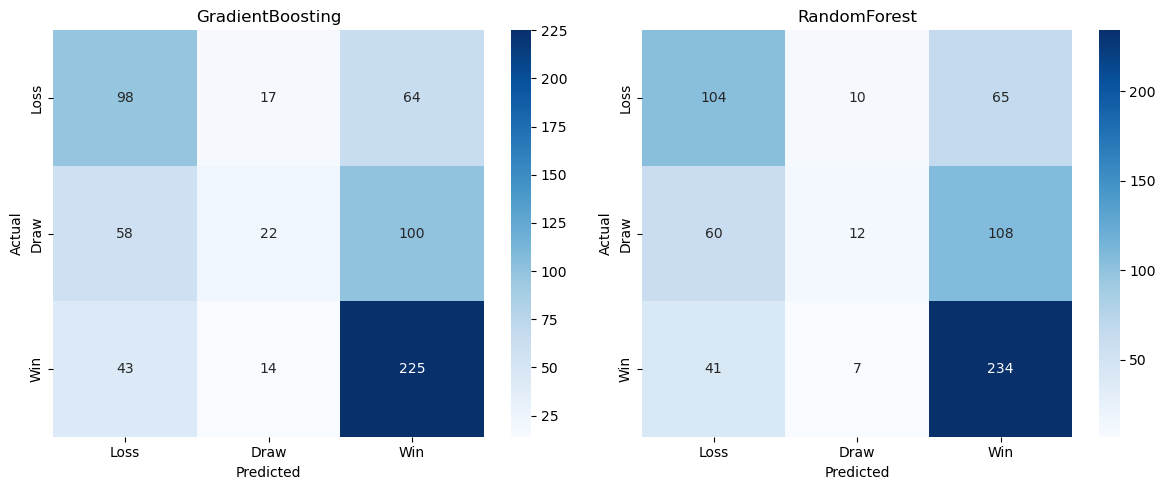

In [300]:
models = {
    'GradientBoosting': GradientBoostingClassifier(n_estimators=200, learning_rate=0.05, max_depth=4, random_state=42),
    'RandomForest'    : RandomForestClassifier(n_estimators=200, max_depth=6, random_state=42),
}

for name, model in models.items():
    print(f"\n{'─'*45}")
    print(f"  {name}")
    print(f"{'─'*45}")

    model.fit(X_train_scaled, y_train)
    
    preds = model.predict(X_test_scaled)
    print(f"  {name} accuracy: {accuracy_score(y_test, preds):.3f}")

    print(f"\n  Classification report (test):")
    print(classification_report(y_test, preds,
                                target_names=['Loss (-1)', 'Draw (0)', 'Win (1)']))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (name, model) in zip(axes, models.items()):
    cm = confusion_matrix(y_test, model.predict(X_test_scaled))
    sns.heatmap(cm, annot=True, fmt='d', ax=ax, cmap='Blues',
                xticklabels=['Loss', 'Draw', 'Win'],
                yticklabels=['Loss', 'Draw', 'Win'])
    ax.set_title(f'{name}')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
plt.tight_layout()
plt.show()

In [302]:
conda install mlflow

Channels:
 - defaults
Platform: osx-arm64
Solving environment: done


==> WARNING: A newer version of conda exists. <==
    current version: 25.1.1
    latest version: 26.5.2

Please update conda by running

    $ conda update -n base -c defaults conda



## Package Plan ##

  environment location: /Users/GraceCeline/miniconda3

  added / updated specs:
    - mlflow


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    alembic-1.18.4             |  py312hca03da5_0         451 KB
    bcrypt-5.0.0               |  py312h931abed_0         215 KB
    cachetools-5.5.1           |  py312hca03da5_0          36 KB
    cloudpickle-3.1.2          |  py312hca03da5_0          73 KB
    databricks-sdk-0.63.0      |  py312hca03da5_0         1.1 MB
    dnspython-2.4.2            |  py312hca03da5_0         488 KB
    docker-py-7.1.0            |  py312hca03da5_0         245 KB
    email-validator-2.3.0     

In [306]:
import joblib
import json
import mlflow
import mlflow.sklearn
from pathlib import Path

# ── save directory ────────────────────────────────────────────────────────────
Path('models').mkdir(exist_ok=True)

# ── save locally with joblib ──────────────────────────────────────────────────
joblib.dump(models['GradientBoosting'], 'models/GradientBoosting.pkl')
joblib.dump(models['RandomForest'],     'models/RandomForest.pkl')

# save feature list (columns used for training)
feature_cols = X_train.columns.tolist()
with open('models/features.json', 'w') as f:
    json.dump(feature_cols, f)

print(f"Saved features: {feature_cols}")

# ── log to mlflow ─────────────────────────────────────────────────────────────
mlflow.set_experiment('wc2026_prediction')

for name, model in models.items():
    with mlflow.start_run(run_name=name):
        # log params
        mlflow.log_params(model.get_params())
        preds = model.predict(X_test_scaled)
        acc = accuracy_score(y_test, preds)
        mlflow.log_metric(f'{name}_accuracy', acc)

        # log classification report as artifact
        report = classification_report(y_test, model.predict(X_test_scaled),
                                        target_names=['Loss', 'Draw', 'Win'],
                                        output_dict=True)
        report_path = f'models/{name}_report.json'
        with open(report_path, 'w') as f:
            json.dump(report, f, indent=2)
        mlflow.log_artifact(report_path)
        mlflow.log_artifact('models/features.json')

        # log model to registry
        mlflow.sklearn.log_model(
            sk_model        = model,
            artifact_path   = name,
            input_example   = X_test.iloc[:1],
        )

        print(f"✓ {name} logged to MLflow")

print("\nDone. Saved:")
print("  models/GradientBoosting.pkl")
print("  models/RandomForest.pkl")
print("  models/features.json")

2026/06/13 21:09:17 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/13 21:09:17 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/06/13 21:09:17 WARNING mlflow.models.signature: Failed to infer the model signature from the input example. Reason: ValueError('X has 10 features, but GradientBoostingClassifier is expecting 2 features as input.'). To see the full traceback, set the logging level to DEBUG via `logging.getLogger("mlflow").setLevel(logging.DEBUG)`.


Saved features: ['neutral', 'home_team_home_winrate', 'home_team_away_winrate', 'away_team_home_winrate', 'away_team_away_winrate', 'elo_diff', 'form_score_diff', 'tournament_weight', 'goal_diff', 'is_home']


2026/06/13 21:09:21 WARNING mlflow.models.model: Failed to validate serving input example {
  "dataframe_split": {
    "columns": [
      "n.... Alternatively, you can avoid passing input example and pass model signature instead when logging the model. To ensure the input example is valid prior to serving, please try calling `mlflow.models.validate_serving_input` on the model uri and serving input example. A serving input example can be generated from model input example using `mlflow.models.convert_input_example_to_serving_input` function.
Got error: X has 10 features, but GradientBoostingClassifier is expecting 2 features as input.
2026/06/13 21:09:21 INFO mlflow.models.model: Found the following environment variables used during model inference: [KAGGLE_API_TOKEN]. Please check if you need to set them when deploying the model. To disable this message, set environment variable `MLFLOW_RECORD_ENV_VARS_IN_MODEL_LOGGING` to `false`.
2026/06/13 21:09:21 WARNING mlflow.models.model: `arti

✓ GradientBoosting logged to MLflow


2026/06/13 21:09:24 WARNING mlflow.models.model: Failed to validate serving input example {
  "dataframe_split": {
    "columns": [
      "n.... Alternatively, you can avoid passing input example and pass model signature instead when logging the model. To ensure the input example is valid prior to serving, please try calling `mlflow.models.validate_serving_input` on the model uri and serving input example. A serving input example can be generated from model input example using `mlflow.models.convert_input_example_to_serving_input` function.
Got error: X has 10 features, but RandomForestClassifier is expecting 2 features as input.


✓ RandomForest logged to MLflow

Done. Saved:
  models/GradientBoosting.pkl
  models/RandomForest.pkl
  models/features.json


# Compare to Elo accuracy

In [307]:
def expected_score(rating_diff):
    return 1 / (1 + 10 ** ((-rating_diff) / 400))


def prob_to_result(prob, win_threshold=0.55, loss_threshold=0.45):
    if prob > win_threshold:
        return 1
    elif prob < loss_threshold:
        return -1
    else:
        return 0

X_test['elo_win_prob'] = X_test['elo_diff'].apply(expected_score)
X_test['elo_pred'] = X_test['elo_win_prob'].apply(prob_to_result)

# evaluate
from sklearn.metrics import accuracy_score, classification_report
acc = accuracy_score(y_test, X_test['elo_pred'])
print(f"Elo baseline accuracy: {acc:.3f}")
print(classification_report(y_test, X_test['elo_pred'],
                            target_names=['Loss (-1)', 'Draw (0)', 'Win (1)']))

Elo baseline accuracy: 0.524
              precision    recall  f1-score   support

   Loss (-1)       0.46      0.69      0.55       179
    Draw (0)       0.27      0.13      0.17       180
     Win (1)       0.65      0.67      0.66       282

    accuracy                           0.52       641
   macro avg       0.46      0.50      0.46       641
weighted avg       0.49      0.52      0.50       641

